# Recurrent Neural Networks (RNN) for Stock Direction Prediction

This notebook explains how a **Many-to-One RNN** works using real market data from urlBinance APIhttps://binance-docs.github.io/apidocs/spot/en/#kline-candlestick-data.

## Goal
Given the last `N` price changes, predict whether the next candle will go:

- `0` → DOWN
- `1` → UP

This is a binary classification problem trained with **CrossEntropyLoss**.

## Why Many-to-One?
- Input: sequence of candles
- Output: one decision for the next candle

This is the standard RNN pattern for:
- sentiment analysis
- fraud detection
- price direction prediction


In [1]:
%%capture
pip install torch pandas requests matplotlib scikit-learn

## 1. Imports

In [2]:
import requests
import warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

device = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
print("Using:", device)


Using: mps


## 2. Download Real Market Data

We use Binance public REST API (no API key required).


In [3]:
from urllib3.exceptions import InsecureRequestWarning
warnings.filterwarnings('ignore', category=InsecureRequestWarning)

def fetch_klines(limit, symbol="BTCUSDT", interval="1m"):
    url = "https://api.binance.com/api/v3/klines"
    params = {
        "symbol": symbol,
        "interval": interval,
        "limit": limit
    }

    r = requests.get(url, params=params, timeout=10, verify=False)

    data = r.json()

    df = pd.DataFrame(data, columns=[
        "open_time","open","high","low","close","volume",
        "close_time","quote_asset_volume","trades",
        "taker_buy_base","taker_buy_quote","ignore"
    ])

    for col in ["open", "high", "low", "close", "volume"]:
        df[col] = df[col].astype(float)

    df["open_time"] = pd.to_datetime(df["open_time"], unit="ms")
    return df

df = fetch_klines(limit=1000000)
df.tail()


,open_time,open,high,low,close,volume,close_time,quote_asset_volume,trades,taker_buy_base,taker_buy_quote,ignore
995,2026-05-16 11:50:00,78118.43,78118.43,78113.56,78113.56,4.82294,1778932259999,376760.25722540,581,0.80429000,62829.86344800,0
996,2026-05-16 11:51:00,78112.73,78112.73,78087.90,78087.91,6.56504,1778932319999,512736.56989520,1191,0.45372000,35435.29631500,0
997,2026-05-16 11:52:00,78087.91,78107.14,78087.90,78092.43,11.10373,1778932379999,867193.66361910,1993,4.63574000,362009.96529230,0
998,2026-05-16 11:53:00,78092.44,78092.44,78092.28,78092.29,7.86587,1778932439999,614264.55743730,353,1.65891000,129548.08481260,0
999,2026-05-16 11:54:00,78092.30,78092.40,78092.29,78092.39,0.92255,1778932499999,72044.08057620,151,0.70241000,54852.83058360,0


## 3. Visualization

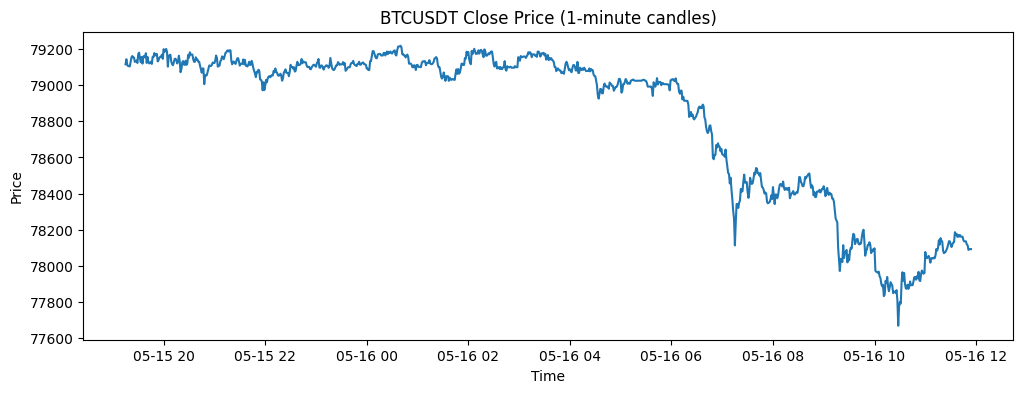

In [4]:
plt.figure(figsize=(12,4))
plt.plot(df["open_time"], df["close"])
plt.title("BTCUSDT Close Price (1-minute candles)")
plt.xlabel("Time")
plt.ylabel("Price")
plt.show()


## 4. Feature Engineering

For each candle, we compute:

- return = `(close_t - close_(t-1)) / close_(t-1)`

Target:

- `1` if next candle closes higher
- `0` otherwise


In [5]:
# Tunable parameters
EASING = 5          # rolling window for volume normalization
HORIZON = 2         # should match training target horizon

df["return"] = df["close"].pct_change()
df["range"] = (df["high"] - df["low"]) / df["close"]

df["volume_z"] = (
    df["volume"] - df["volume"].rolling(EASING).mean()
) / df["volume"].rolling(EASING).std()

future_return = df["close"].shift(-HORIZON) / df["close"] - 1
df["target"] = (future_return > 0).astype(int)

df = df.dropna().reset_index(drop=True)

features = ["return", "range", "volume_z"]

# Save training normalization stats for later live inference.
feature_stats = {}
for col in features:
    mean = df[col].mean()
    std = df[col].std()
    if std == 0:
        std = 1.0
    feature_stats[col] = {"mean": float(mean), "std": float(std)}
    df[col] = (df[col] - mean) / std

df[features].tail()



,return,range,volume_z
991,-0.152169,-0.712041,0.303401
992,-0.973509,0.061640,1.038312
993,0.218443,-0.155063,1.850385
994,0.034286,-0.894531,0.235526
995,0.043770,-0.896469,-1.531612


## 5. Create Sequences

Each sample contains the last `SEQ_LEN` returns.


In [6]:
SEQ_LEN = EASING * 2  # should be >= EASING to have enough history for normalization

def build_sequences(values, targets, seq_len):
    X, y = [], []
    for i in range(seq_len, len(values)):
        X.append(values[i-seq_len:i])
        y.append(targets[i])
    return np.array(X), np.array(y)

X, y = build_sequences(
    df[features].values,    # shape: (rows, 3) # .reshape(-1, 1),
    df["target"].values,
    SEQ_LEN
)

print("X shape:", X.shape)  # (samples, seq_len, features)
print("y shape:", y.shape)


X shape: (986, 10, 3)
y shape: (986,)


## 6. Train/Test Split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

class SequenceDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(SequenceDataset(X_train, y_train), batch_size=64, shuffle=True)
test_loader = DataLoader(SequenceDataset(X_test, y_test), batch_size=64)


## 7. RNN Architecture

Many-to-One RNN:

- Input shape: `(batch, seq_len, features)`
- RNN processes sequence step by step
- Last hidden state summarizes the whole sequence
- Linear layer converts hidden state to 2 logits


genui{"math_block_widget_always_prefetch_v2":{"content":"h_t = \tanh(W_{xh}x_t + W_{hh}h_{t-1} + b)"}}

In [8]:
class PriceRNN(nn.Module):
    def __init__(self, input_size=1, hidden_size=320, num_layers=1):
        super().__init__()
        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, 2)

    def forward(self, x):
        output, hidden = self.rnn(x)
        last_hidden = hidden[-1]      # (batch, hidden_size)
        logits = self.fc(last_hidden) # (batch, 2)
        return logits

model = PriceRNN(input_size=len(features)).to(device)
model


PriceRNN(
  (rnn): RNN(3, 320, batch_first=True)
  (fc): Linear(in_features=320, out_features=2, bias=True)
)

## 8. CrossEntropy Loss

`CrossEntropyLoss` combines:
- softmax
- negative log-likelihood

Target labels are integers:
- 0 = DOWN
- 1 = UP


In [9]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


## 9. Training Loop

In [10]:
def evaluate(loader):
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for Xb, yb in loader:
            Xb, yb = Xb.to(device), yb.to(device)
            logits = model(Xb)
            preds = logits.argmax(dim=1)
            correct += (preds == yb).sum().item()
            total += len(yb)
    return correct / total

EPOCHS = 1000
history = []

for epoch in range(EPOCHS):
    model.train()
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(device), yb.to(device)

        optimizer.zero_grad()
        logits = model(Xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

    train_acc = evaluate(train_loader)
    test_acc = evaluate(test_loader)
    history.append((train_acc, test_acc))

    print(
        f"Epoch {epoch+1:02d} | "
        f"Train: {train_acc:.3f} | "
        f"Test: {test_acc:.3f}"
    )


Epoch 01 | Train: 0.557 | Test: 0.520
Epoch 02 | Train: 0.570 | Test: 0.551
Epoch 03 | Train: 0.580 | Test: 0.561
Epoch 04 | Train: 0.580 | Test: 0.556
Epoch 05 | Train: 0.574 | Test: 0.530
Epoch 06 | Train: 0.574 | Test: 0.551
Epoch 07 | Train: 0.584 | Test: 0.530
Epoch 08 | Train: 0.602 | Test: 0.566
Epoch 09 | Train: 0.569 | Test: 0.540
Epoch 10 | Train: 0.593 | Test: 0.530
Epoch 11 | Train: 0.572 | Test: 0.525
Epoch 12 | Train: 0.589 | Test: 0.545
Epoch 13 | Train: 0.599 | Test: 0.535
Epoch 14 | Train: 0.595 | Test: 0.530
Epoch 15 | Train: 0.590 | Test: 0.551
Epoch 16 | Train: 0.579 | Test: 0.551
Epoch 17 | Train: 0.594 | Test: 0.551
Epoch 18 | Train: 0.582 | Test: 0.535
Epoch 19 | Train: 0.580 | Test: 0.540
Epoch 20 | Train: 0.585 | Test: 0.561
Epoch 21 | Train: 0.607 | Test: 0.566
Epoch 22 | Train: 0.588 | Test: 0.561
Epoch 23 | Train: 0.605 | Test: 0.561
Epoch 24 | Train: 0.588 | Test: 0.561
Epoch 25 | Train: 0.590 | Test: 0.566
Epoch 26 | Train: 0.610 | Test: 0.551
Epoch 27 | T

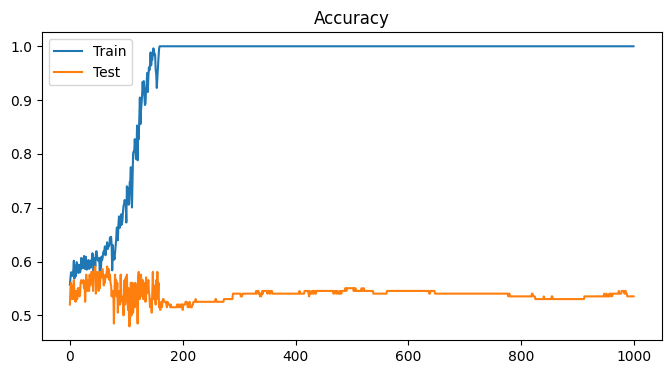

In [11]:
plt.figure(figsize=(8,4))
plt.plot([x[0] for x in history], label="Train")
plt.plot([x[1] for x in history], label="Test")
plt.title("Accuracy")
plt.legend()
plt.show()


## 10. Inspect Predictions

Probability of UP is the model confidence.


In [12]:
def predict_up_probability(sequence):
    model.eval()
    x = torch.tensor(sequence, dtype=torch.float32).unsqueeze(0).to(device)
    with torch.no_grad():
        logits = model(x)
        probs = torch.softmax(logits, dim=1)
    return probs[0, 1].item()

sample = X_test[-1]
p_up = predict_up_probability(sample)

print("Probability of UP:", round(p_up, 4))
print("Decision:", "BUY" if p_up >= 0.67 else "SELL" if p_up <= 0.33 else "HOLD")


Probability of UP: 0.0
Decision: SELL


## 11. Live Trading Simulator

Rules:
- `0.67 - 1.00` → BUY
- `0.33 - 0.67` → HOLD
- `0.00 - 0.33` → SELL

This is educational only and does **not** place real orders.


In [13]:
import time

# Tunable parameters
MAX_ACTIONS = 20
START_CASH = 100.0
LEVERAGE = 100


def engineer_features(df, easing=EASING):
    """
    Apply exactly the same feature engineering as during training.
    """
    df = df.copy()

    df["return"] = df["close"].pct_change()
    df["range"] = (df["high"] - df["low"]) / df["close"]
    df["volume_z"] = (
        df["volume"] - df["volume"].rolling(easing).mean()
    ) / df["volume"].rolling(easing).std()

    # Use the same feature list and statistics from training
    for col in features:
        mean = feature_stats[col]["mean"]
        std = feature_stats[col]["std"]
        df[col] = (df[col] - mean) / std

    return df.dropna().reset_index(drop=True)


def fetch_latest_sequence(symbol="BTCUSDT", interval="1m", seq_len=SEQ_LEN):
    """
    Download enough candles to:
    - compute rolling statistics,
    - remove NaNs,
    - keep the last SEQ_LEN rows.
    """
    limit = seq_len + EASING + 10

    live = fetch_klines(
        symbol=symbol,
        interval=interval,
        limit=limit
    )

    live = engineer_features(live)

    if len(live) < seq_len:
        raise ValueError("Not enough data to build sequence")

    seq = live[features].values[-seq_len:]
    price = live["close"].iloc[-1]

    return seq, price


def decide(p_up):
    if p_up >= 0.67:
        return "BUY"
    elif p_up <= 0.33:
        return "SELL"
    else:
        return "HOLD"


def play_trader(symbol="BTCUSDT", interval="1s", delay=60):
    cash = START_CASH
    position = None          # BUY or SELL
    stake = 1.0
    actions = 0

    print(f"Starting cash: {cash:.2f}")
    print()

    while actions < MAX_ACTIONS and 0 < cash < 200:
        seq, price = fetch_latest_sequence(symbol, interval)
        p_up = predict_up_probability(seq)
        action = decide(p_up)

        print(f"= {actions} ","=" * 60)
        print(f"Price   : {price:.2f}; P(UP)   : {p_up:.4f}; Signal  : {action}")
        print(f"Position: {position}; Stake   : x{stake:.0f}")
        print(f"Cash    : {cash:.2f}")

        # HOLD does nothing
        if action == "HOLD":
            print("Decision: HOLD")
            time.sleep(delay)
            continue

        # First action: open position
        if position is None:
            position = action
            actions += 1
            print(f"Opened {position}")
            time.sleep(delay)
            continue

        # Same direction: martingale (double stake)
        if action == position:
            stake *= 2
            actions += 1
            print(f"Same signal -> doubling to x{stake:.0f}")
            time.sleep(delay)
            continue

        # Opposite direction: cash out
        # Educational payout model:
        # cash changes by stake percent
        pnl = cash * (stake / LEVERAGE)

        if position == "BUY":
            cash += pnl
        else:
            cash -= pnl

        print(f"Closed {position}")
        print(f"PnL     : {pnl:+.2f}")
        print(f"Cash    : {cash:.2f}")

        # Open new opposite position
        position = action
        stake = 1.0
        actions += 1

        print(f"Opened {position}")

        # Break conditions
        if cash <= 0:
            print("\nBANKRUPT")
            break

        if cash >= 200:
            print("\nTARGET REACHED")
            break

        time.sleep(delay)

    print()
    print("=" * 60)
    print(f"Finished after {actions} actions")
    print(f"Final cash: {cash:.2f}")


# Run once per minute (set delay=2 for demo purposes)
play_trader(delay=2)

Starting cash: 100.00

= 0  ============================================================
Price   : 78075.14; P(UP)   : 0.0001; Signal  : SELL
Position: None; Stake   : x1
Cash    : 100.00
Opened SELL
= 1  ============================================================
Price   : 78075.14; P(UP)   : 0.0000; Signal  : SELL
Position: SELL; Stake   : x1
Cash    : 100.00
Same signal -> doubling to x2
= 2  ============================================================
Price   : 78075.15; P(UP)   : 0.8826; Signal  : BUY
Position: SELL; Stake   : x2
Cash    : 100.00
Closed SELL
PnL     : +2.00
Cash    : 98.00
Opened BUY
= 3  ============================================================
Price   : 78075.15; P(UP)   : 0.0000; Signal  : SELL
Position: BUY; Stake   : x1
Cash    : 98.00
Closed BUY
PnL     : +0.98
Cash    : 98.98
Opened SELL
= 4  ============================================================
Price   : 78075.14; P(UP)   : 0.0015; Signal  : SELL
Position: SELL; Stake   : x1
Cash    : 98.98
Same

In [14]:
# Optional: monitor every minute
# while True:
#     print("=" * 40)
#     trader_step()
#     time.sleep(60)


## 12. Key Takeaways

### Why RNN Works
RNN maintains a hidden state that accumulates information over time.

### Hidden State Intuition
The model learns patterns such as:
- momentum
- reversals
- short-term trends

### Many-to-One Pattern
A whole sequence is compressed into one final decision.

### CrossEntropy
Measures how well the predicted probabilities match the true label.

### Limitations
- Price movement is noisy.
- Accuracy may be close to random.
- Educational value is more important than profitability.

### Next Lessons
- LSTM
- GRU
- Attention
- Transformer-based forecasting
